# MDMR R Notebook

This notebook demonstrates basic usage of the `mdmr` package, including visualization and model fitting.

In [6]:
library(mdmr)
library(ggplot2)

y <- mdmr::y
y <- read.csv("../mdmp/data/covid_regional_timeseries.csv")
# y <- read.csv("./data/dag_5var_simulated.csv")


,Y1,Y2,Y3,Y4
,<dbl>,<dbl>,<dbl>,<dbl>
1,-6.1321001,-11.210444,-7.283991,-16.075637
2,16.2922322,7.415729,-5.656067,12.150740
3,15.9534579,13.000213,-3.744846,-3.317547
4,-16.3264156,-1.952344,4.994592,9.167856
5,0.3482551,-1.353144,1.710518,0.384896
6,-9.1254934,-2.152148,-3.419737,-7.484200


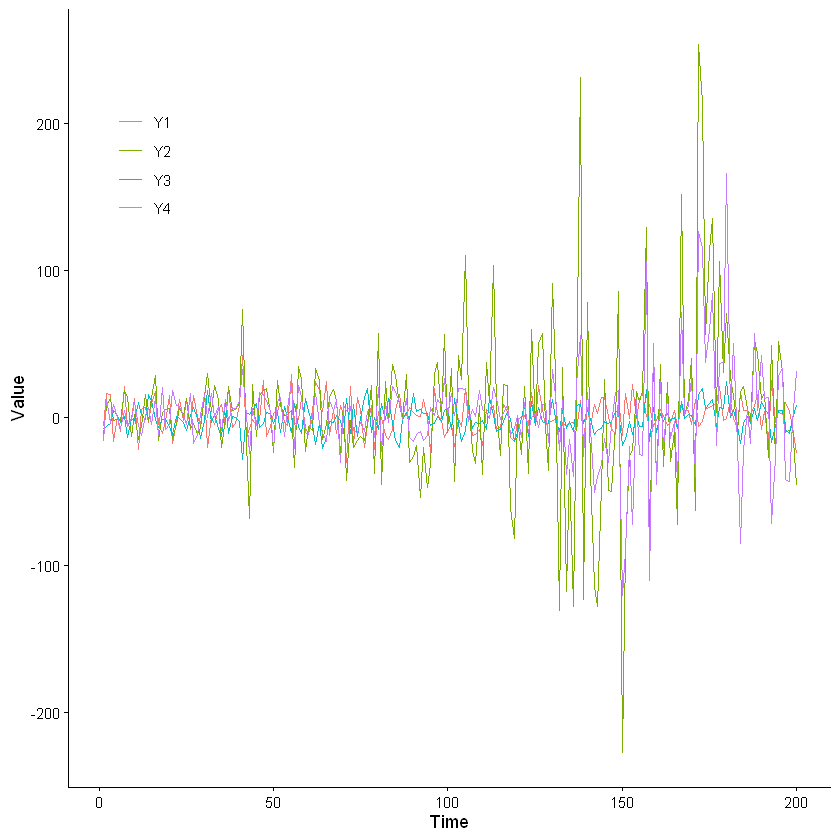

In [7]:
head(mdmr::y)
long_df <- stack(mdmr::y)
long_df$obs <- rep(seq_len(nrow(mdmr::y)), times = ncol(mdmr::y))
names(long_df) <- c("Value", "name", "Time")
long_df |> 
  ggplot2::ggplot(ggplot2::aes(x = Time, y = Value, colour = name)) +
  ggplot2::geom_line() +
  ggplot2::theme_classic() +
  ggplot2::theme(legend.position = c(.1, .8), legend.title = ggplot2::element_blank())

## 2. Fit the MDM model

In [8]:
res <- mdm(data_input = y, method = "hc")

Running bnlearn::hc() with MDM custom score...



Warning message in ggraph::geom_node_label(ggplot2::aes(label = name), label.size = NA, :
"Ignoring unknown parameters: `label.size`"


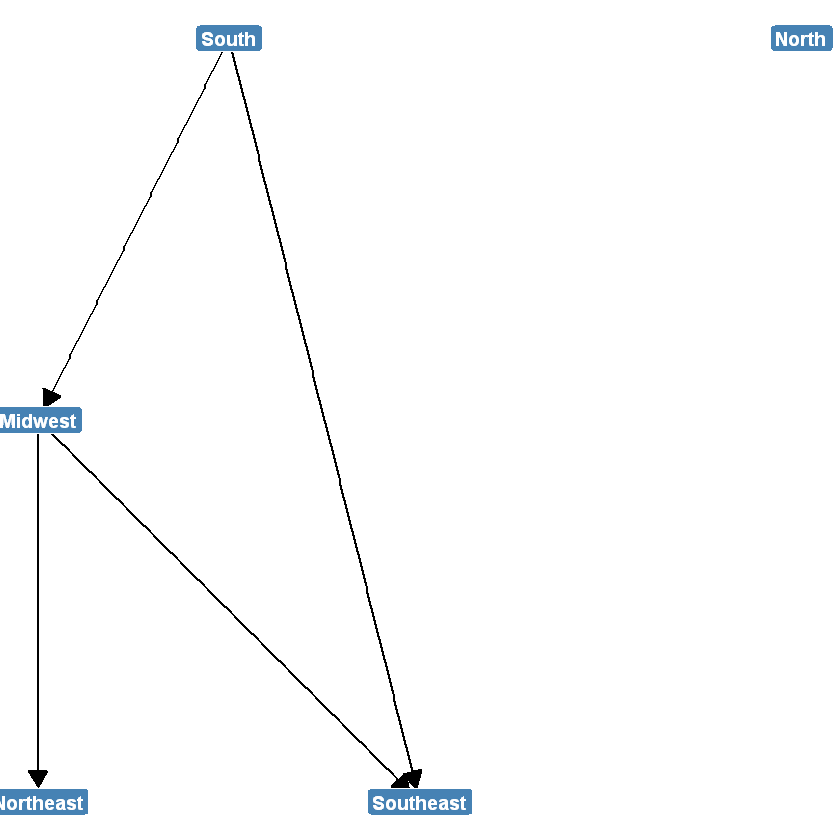

In [9]:
plot_dag(res, type = "graph")

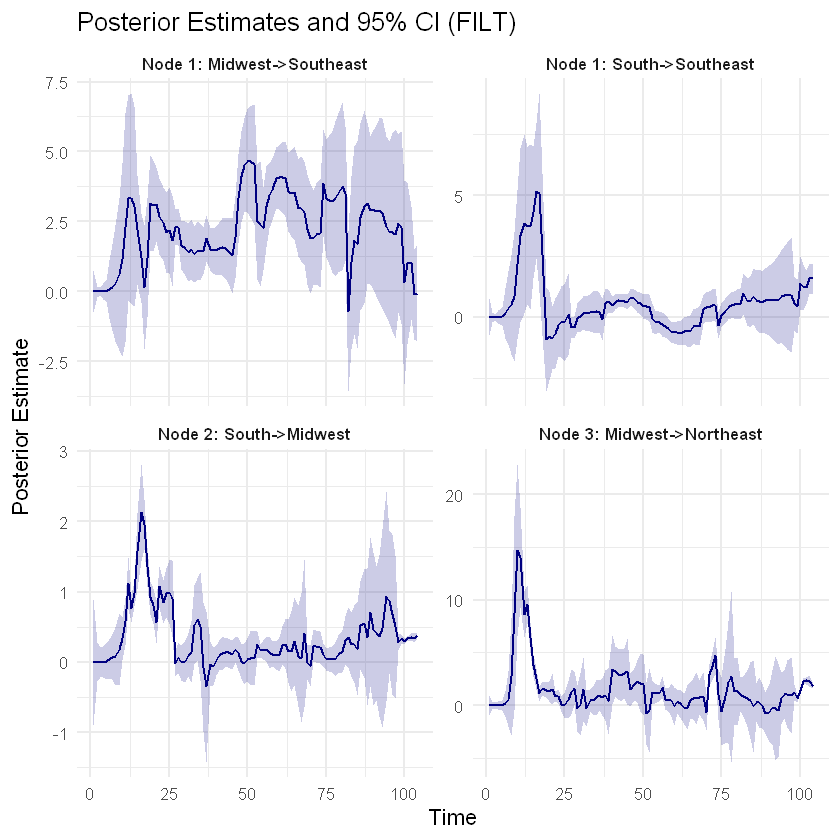

In [10]:
plot_arcs(res, type = "connections", distribution = "filt", ci_level = 0.95)